<a href="https://colab.research.google.com/github/giovanisaavedra/FIAP/blob/main/ANO%201/FASE%2005/CAP%201%20-%20FARMTECH%20NA%20ERA%20DO%20CLOUD%20COMPUTING/00%20-%20PROJETO/GiovaniSaavedra_rm566797_pbl_fase5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CAP 1 - FARMTECH NA ERA DO CLOUD COMPUTING - 09/02/2026 a 18/03/2026 ###
## PROJETO FASE 5 – MACHINE LEARNING NA CABEÇA ##

Baseado no dataset “crop_yield.csv”, o projeto consiste em:

1) Fazer uma análise exploratória na base para se familiarizar com os dados;
2) Encontrar tendências para os rendimentos das plantações, por meio de clusterizações, e identificar se existem cenários discrepantes (outliers);
3) Fazer cinco modelos preditivos (cada um com um algoritmo diferente, conforme visto no capítulo “Modelagem de Dados com Regressão Supervisionada”) que, dadas as condições, prevejam qual será o rendimento da safra. Esta parte da tarefa inclui seguir as boas práticas dos projetos de Machine Learning, assim como avaliar o modelo com métricas pertinentes ao problema.


In [ ]:
!pip install numpy pandas seaborn scikit-learn matplotlib

# **I. ANÁLISE EXPLORATÓRIA DE DADOS (EDA) **

In [68]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import cross_val_score

In [5]:
# ======================================================
# CARREGAMENTO DO DATASET
# ======================================================
# Para executar este notebook no Google Colab:
# 1. Execute esta célula
# 2. Clique em "Escolher arquivo" e selecione o arquivo crop_yield.csv
#    (disponível na pasta assets/ deste repositório)
# ======================================================
from google.colab import files

uploaded = files.upload()
df = pd.read_csv("crop_yield.csv")

Saving crop_yield.csv to crop_yield.csv


In [3]:
#Exibir primeiras linhas do DataFrame
df.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


##**ANÁLISE 01 - VISÃO GERAL DOS DADOS**

no primeio momento de uma EDA, busca-se ter uma visão geral dos dados. A primeira análise tradicional é avaliar as primeiras linhas do data frame para confirmar se o dataset carregou adequadamente e entender o tipo de dados que estamos lidando. Já foi possível perceber, por exemplo, nessa primeira análise perceber que temos uma coluna com dados categóricos (Crop) que vai precisar de tratamento especial (encoding, ou seja, transformar texto em números) para entrar nos modelos.

In [10]:
df

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800
...,...,...,...,...,...,...
151,"Rubber, natural",2308.51,18.27,83.65,26.47,6721
152,"Rubber, natural",2410.13,18.58,83.45,26.81,6248
153,"Rubber, natural",2967.41,18.67,85.48,26.46,6842
154,"Rubber, natural",2333.46,18.50,84.85,26.43,5571


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


In [6]:
df["Crop"].value_counts()

,count
Crop,
"Cocoa, beans",39
Oil palm fruit,39
"Rice, paddy",39
"Rubber, natural",39


##**ANÁLISE 02 - DESCRIÇÃO DE DADOS**

O dataset possui:
1) 156 registros (linhas);
2) 6 variáveis (colunas): 1 categórica (Cultura), 4 numéricas contínuas(variáveis climáticas), 1 numérica inteira (Rendimento - variável alvo);
3) 4 tipos de cultura, cada uma com 39 registros (dataset perfeitamente balanceado por cultura);
4) Nenhum valor ausente;
5) Percebemos também que os dados estão balanceados.


##**ANÁLISE 03 - QUANTIDADE DE DADOS**

A quantidade de dados é fundamental para analisarmos se temos dados suficientes para uma clusterização confiável e para dividir os dados em conjuntos de treino/teste para regressão.
Com 156 registros estamos trabalhando com uma dataset pequeno, o que significa, por exemplo, que técnicas como cross-validation serão importantes na etapa de criação de modelos preditivos para aproveitramos cadas dado disponível ou, essa informação, também serve para avaliarmos se não seria necessário criar dados artificais para complementar os dados atuais e melhorar o desempenho dos modelos.

In [7]:
df.describe()

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


#**ANÁLISE 04 - ESTATÍSTICAS DESCRITIVAS**

1) As variáveis estão em escalas diferentes, então, haverá necessidade de padronização;
2) Com exceção do Yield, as variáveis climáticas apresentam baixa dispersão relativa. Essa análise é feita pelo Coeficiente de Variação (CV), calculado pela relação entre o desvio padrão (std) e a média. Quando o CV é muito alto (caso do Yield, 125,4%), os dados estão extremamente dispersos — o que justifica a necessidade de analisar essa coluna mais de perto nas próximas etapas.
Entre as variáveis climáticas, embora todas tenham baixa dispersão comparadas ao Yield, elas não são iguais entre si. Precipitação apresenta a maior dispersão relativa (CV=11,6%), quase 10 vezes superior à Temperatura (CV=1,0%), que é a variável com menor variação. Umidade Específica (CV=1,6%) e Umidade Relativa (CV=1,2%) também variam muito pouco. Isso indica que, dentre as variáveis climáticas, Precipitação é a que tem maior potencial para diferenciar os registros entre si — informação que será útil nas etapas de clusterização e modelagem preditiva.

In [8]:
df.groupby("Crop")["Yield"].describe()

,count,mean,std,min,25%,50%,75%,max
Crop,,,,,,,,
"Cocoa, beans",39.0,8883.128205,1745.030586,5765.0,7729.0,8848.0,9918.0,13056.0
Oil palm fruit,39.0,175804.692308,14919.869752,142425.0,166017.5,175629.0,185230.0,203399.0
"Rice, paddy",39.0,32099.666667,4789.948436,24686.0,28293.5,31101.0,36098.5,42550.0
"Rubber, natural",39.0,7824.897436,1600.255042,5249.0,6398.0,7817.0,9272.5,10285.0


Porém, quando analisamos de maneira isolada as estatísticas descritivas por cultura, percebemos que o coeficiente de variação não indica dispersão significativa: Oil palm fruit (8,5%), Rice, paddy (14,9%), Cocoa, beans (19,6%) e Rubber, natural (20,5%). Isso evidencia que a alta dispersão global (125,4%) é causada pela diferença natural de rendimento entre culturas, e não por inconsistência nos dados.


In [12]:
# Compara os valores de Precipitação entre as culturas
for crop in df["Crop"].unique():
    print(crop)
    print(df[df["Crop"] == crop]["Precipitation (mm day-1)"].values[:5])
    print()

Cocoa, beans
[2248.92 1938.42 2301.54 2592.35 2344.72]

Oil palm fruit
[2248.92 1938.42 2301.54 2592.35 2344.72]

Rice, paddy
[2248.92 1938.42 2301.54 2592.35 2344.72]

Rubber, natural
[2248.92 1938.42 2301.54 2592.35 2344.72]



Uma descoberta importante da análise descritiva é que as variáveis climáticas são idênticas para todas as culturas — os mesmos 39 registros de condições climáticas se repetem para cada uma das 4 culturas, variando apenas o rendimento. Isso indica que os dados representam a mesma região geográfica, e que o tipo de cultura é o principal fator diferenciador do rendimento. Essa observação será determinante nas etapas de clusterização e modelagem preditiva.

Clusterização: se a clusterização usar variáveis climáticas + Yield, os clusters vão se formar essencialmente pela diferença de Yield entre culturas, já que o clima é igual para todas.

Regressão: A variável Cultura (Crop) se torna absolutamente crucial como feature. Sem ela, dois registros com clima idêntico mas culturas diferentes teriam Yields completamente diferentes, e o modelo não conseguiria distinguir. Portanto, o encoding da coluna Crop será determinante para o desempenho dos modelos.

##**ANÁLISE 05 - DISTRIBUIÇÃO DE VARIÁVEIS**


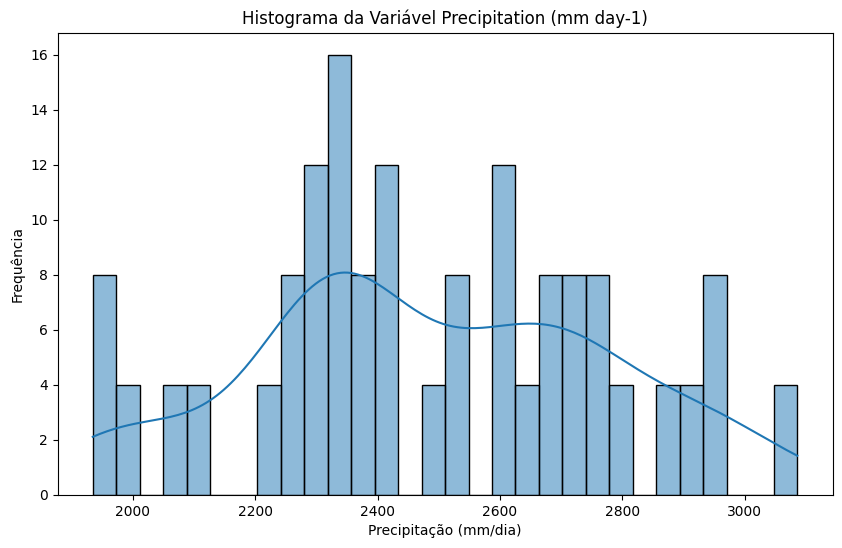

In [19]:

# == Historiograma da variável Precipitation (mm day-1) ==
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="Precipitation (mm day-1)", bins=30, kde=True)
plt.title("Histograma da Variável Precipitation (mm day-1)")
plt.xlabel("Precipitação (mm/dia)")
plt.ylabel("Frequência")
plt.show()


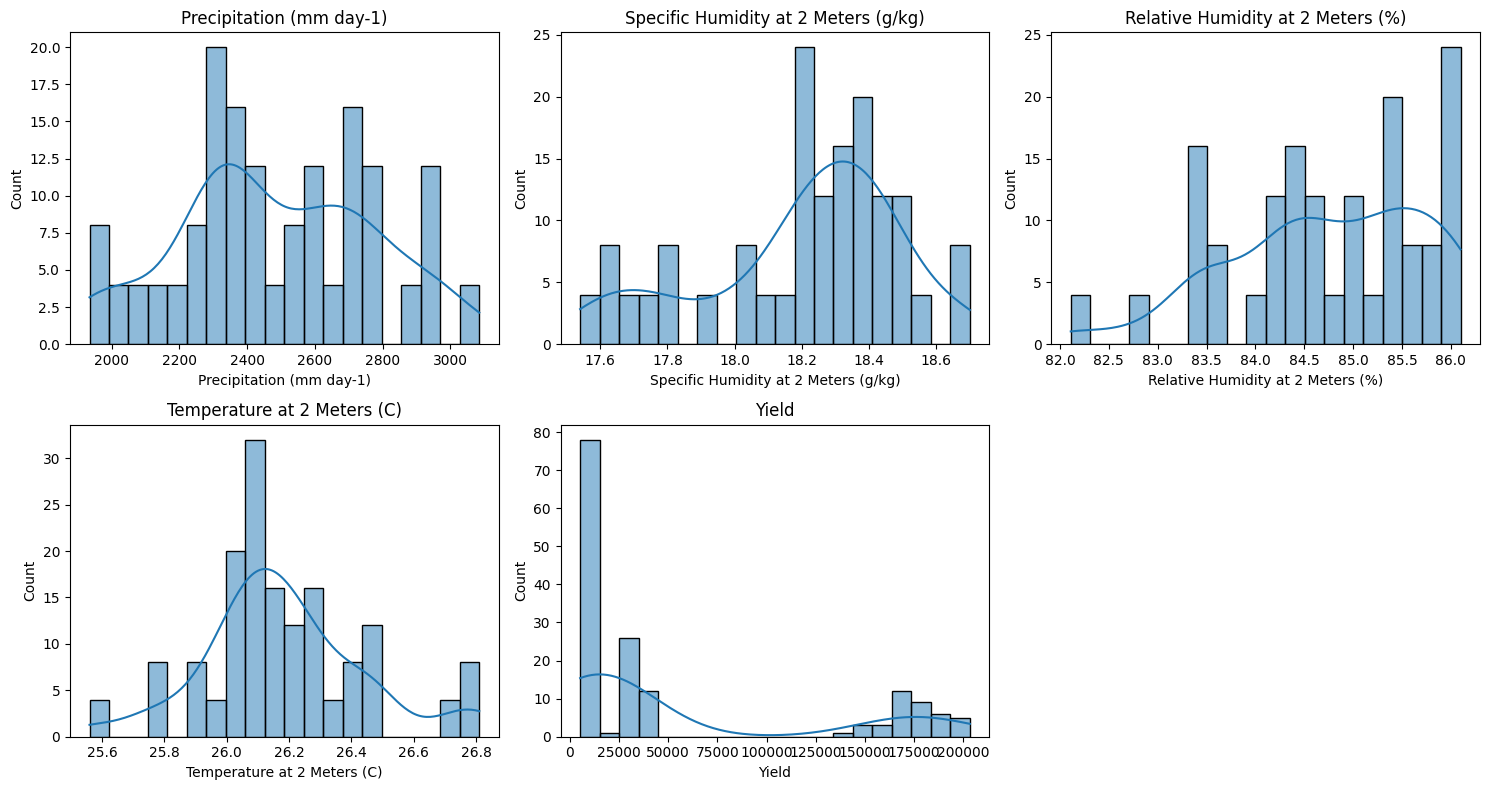

In [21]:
# == Historiograma com subplots de todas as variáveis ==

colunas_numericas = df.select_dtypes(include="number").columns.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes_flat = axes.flatten()
for i, coluna in enumerate(colunas_numericas):
  sns.histplot(data=df, x=coluna, bins=20, kde=True, ax=axes_flat[i])
  axes_flat[i].set_title(f"{coluna}")

axes_flat[5].set_visible(False)
plt.tight_layout()
plt.show()

In [22]:
df[df["Yield"] <= 25000]["Crop"].value_counts()

,count
Crop,
"Cocoa, beans",39
"Rubber, natural",39
"Rice, paddy",1


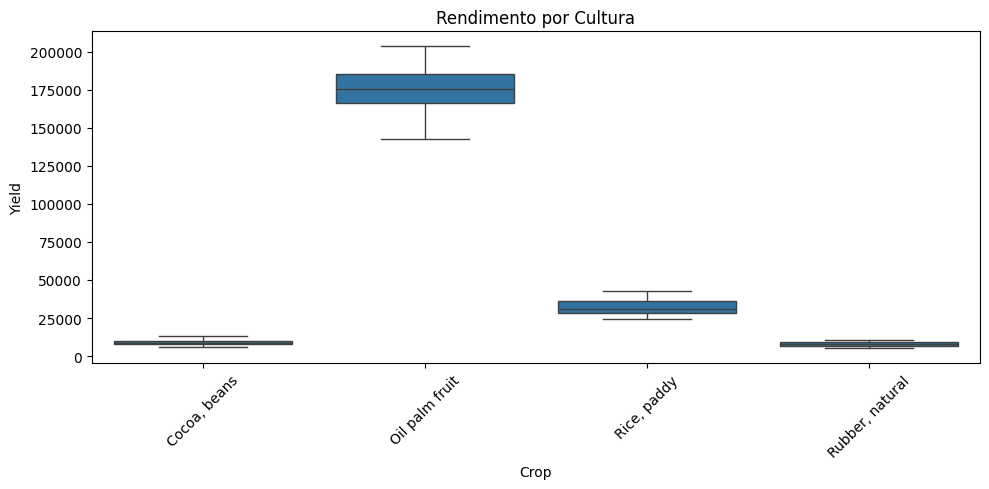

In [23]:
# Boxplot do Yield por Cultura
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Crop", y="Yield")
plt.title("Rendimento por Cultura")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

O boxplot de Rendimento por Cultura confirma que Oil palm fruit apresenta rendimento significativamente superior às demais culturas, com valores na faixa de 140.000 a 203.000. Rice, paddy ocupa uma faixa intermediária (~25.000 a 42.000), enquanto Cocoa, beans e Rubber, natural apresentam rendimentos semelhantes entre si, na faixa de 5.000 a 13.000. Esses intervalos são consistentes com os valores de mínimo e máximo observados nas estatísticas descritivas por cultura (groupby + describe).

Embora o boxplot sugira que Oil palm fruit possui a maior dispersão, a análise do coeficiente de variação (calculado a partir do desvio padrão e da média obtidos nas estatísticas descritivas) revela uma realidade diferente: com CV de 8,5%, Oil palm fruit é a cultura com rendimento mais previsível. Em contrapartida, Rubber, natural, apesar de aparentar menor dispersão no boxplot, possui o maior coeficiente de variação (20,5%), sendo a cultura com rendimento mais imprevisível proporcionalmente. Isso evidencia a importância de complementar a análise visual com métricas numéricas para evitar conclusões equivocadas.

Implicações para as próximas etapas: A diferença significativa de escala de rendimento entre culturas indica que, na clusterização, os agrupamentos tendem a se formar primariamente pela separação entre culturas. Dessa forma, será importante avaliar se os clusters revelam padrões além dessa separação óbvia, como variações de desempenho dentro de uma mesma cultura sob diferentes condições climáticas.

Para a modelagem preditiva, a variação proporcional de cada cultura (CV de 8,5% a 20,5%) sugere que os modelos terão maior facilidade em prever o rendimento de Oil palm fruit e maior dificuldade com Rubber, natural.

Essas hipóteses serão verificadas nas etapas seguintes.

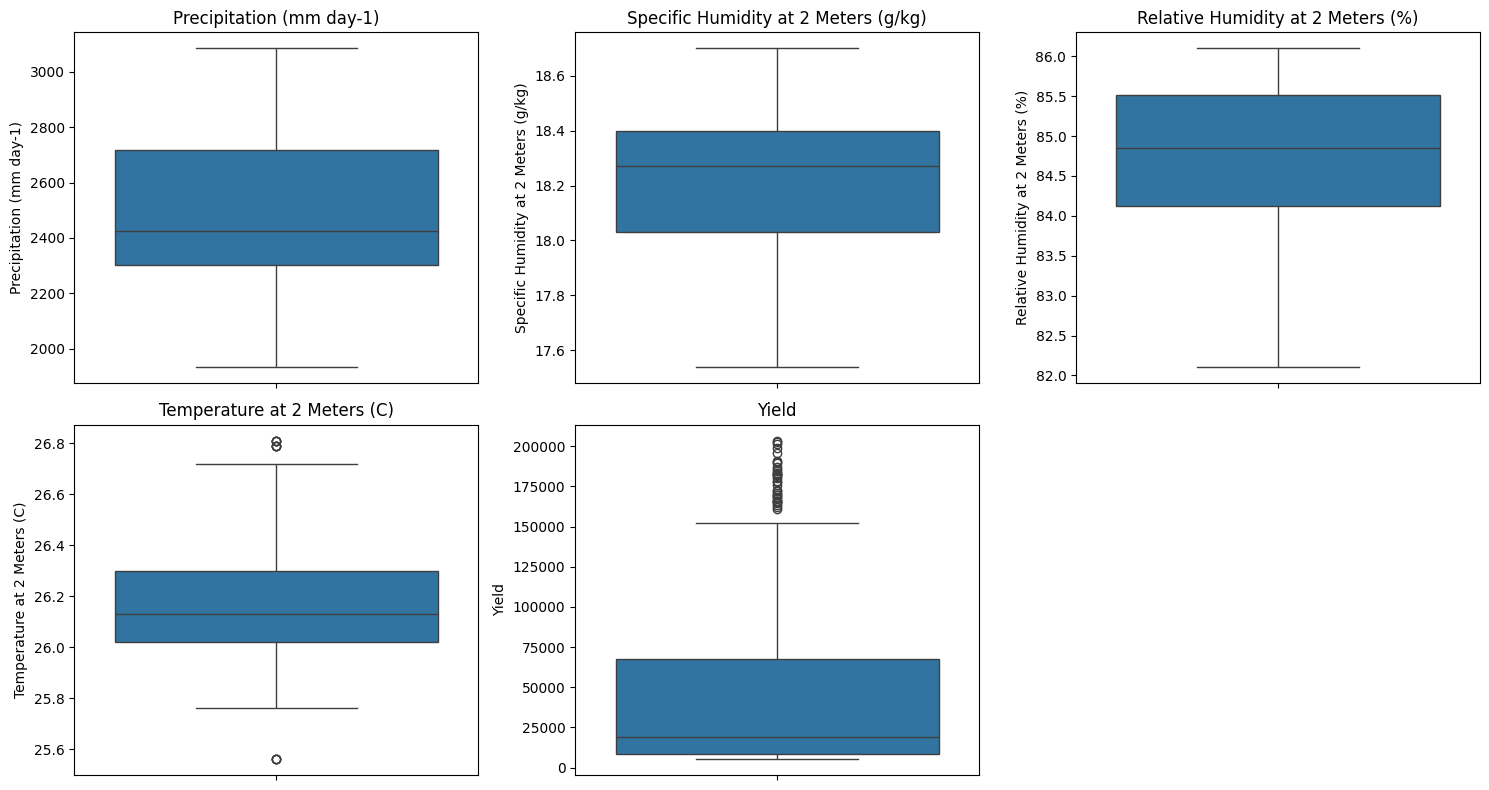

In [24]:
# == Boxplots de todas as variáveis numéricas ==

colunas_numericas = df.select_dtypes(include="number").columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes_flat = axes.flatten()

for i, coluna in enumerate(colunas_numericas):
    sns.boxplot(data=df, y=coluna, ax=axes_flat[i])  # y= para boxplot vertical
    axes_flat[i].set_title(f"{coluna}")

axes_flat[5].set_visible(False)
plt.tight_layout()
plt.show()

Análise dos Boxplots Individuais

Os boxplots das variáveis numéricas revelam que apenas duas variáveis apresentam pontos isolados fora dos bigodes (outliers): Temperature at 2 Meters e Yield.

No caso do Yield, os pontos que aparecem como outliers no boxplot correspondem aos registros de Oil palm fruit, conforme já observado nas análises anteriores. Como a diferença de rendimento entre culturas é natural e não uma anomalia, esses valores não devem ser considerados outliers verdadeiros.

Já os outliers de Temperature indicam registros com temperaturas acima do padrão geral, o que pode representar períodos de calor atípico na região da fazenda.

As demais variáveis climáticas (Precipitation, Specific Humidity e Relative Humidity) não apresentam outliers, indicando dados consistentes e sem valores atípicos.

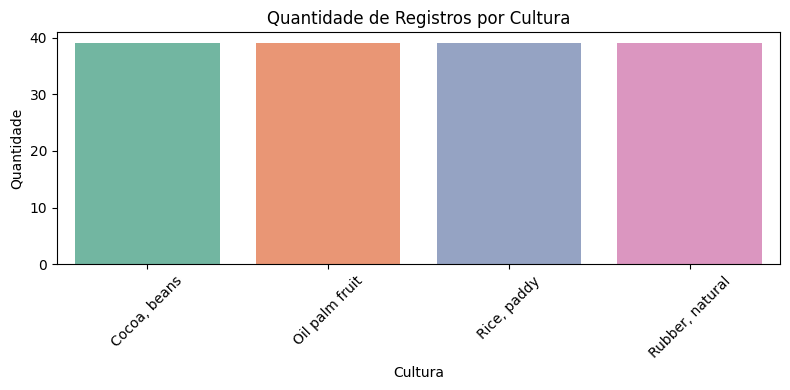

In [33]:
# == Contagem de registros por cultura ==

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Crop", hue="Crop", palette="Set2", legend=False)
plt.title("Quantidade de Registros por Cultura")
plt.xlabel("Cultura")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

O countplot confirma visualmente que o dataset é perfeitamente balanceado, com 39 registros para cada uma das 4 culturas.

##**ANÁLISE 06 - CORRELAÇÃO ENTRE VARIÁVEIS (ANÁLISE BIVARIADA)**

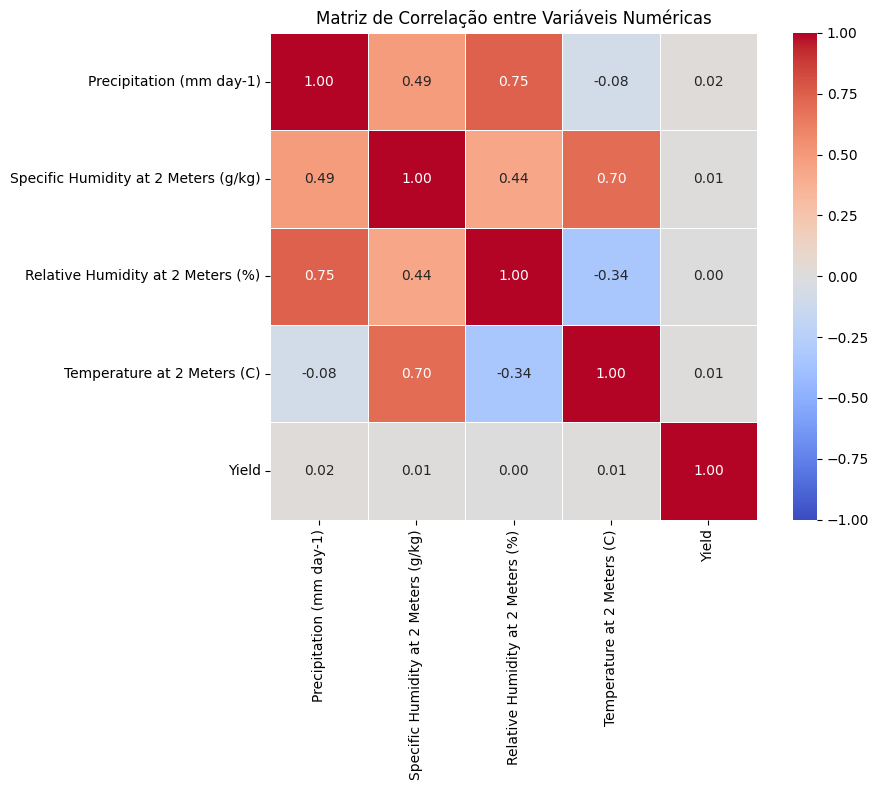

In [26]:
# == Matriz de Correlação ==

plt.figure(figsize=(10, 8))
sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,       # mostra os números dentro das células
    fmt=".2f",        # duas casas decimais
    cmap="coolwarm",  # vermelho = positivo, azul = negativo
    vmin=-1, vmax=1,  # fixa a escala de -1 a 1
    square=True,      # células quadradas
    linewidths=0.5    # linhas de separação
)
plt.title("Matriz de Correlação entre Variáveis Numéricas")
plt.tight_layout()
plt.show()

A matriz de correlação revela que nenhuma variável climática apresenta correlação significativa com o Yield (valores próximos de zero). Isso é coerente com a descoberta anterior de que os dados climáticos são idênticos para todas as culturas — o mesmo valor de precipitação ou temperatura aparece associado a rendimentos completamente diferentes dependendo da cultura. Portanto, a variável Crop (categórica, não presente na matriz de correlação) é o principal fator explicativo do rendimento, reforçando que seu encoding será indispensável na modelagem preditiva.

Embora as variáveis climáticas não apresentem correlação com o Yield, existem correlações relevantes entre elas: Precipitação e Umidade Relativa (0,75) e Umidade Específica e Temperatura (0,70). Essa multicolinearidade indica que parte da informação entre essas variáveis é redundante, o que deverá ser considerado na escolha e interpretação dos modelos de regressão na última etapa do projeto.

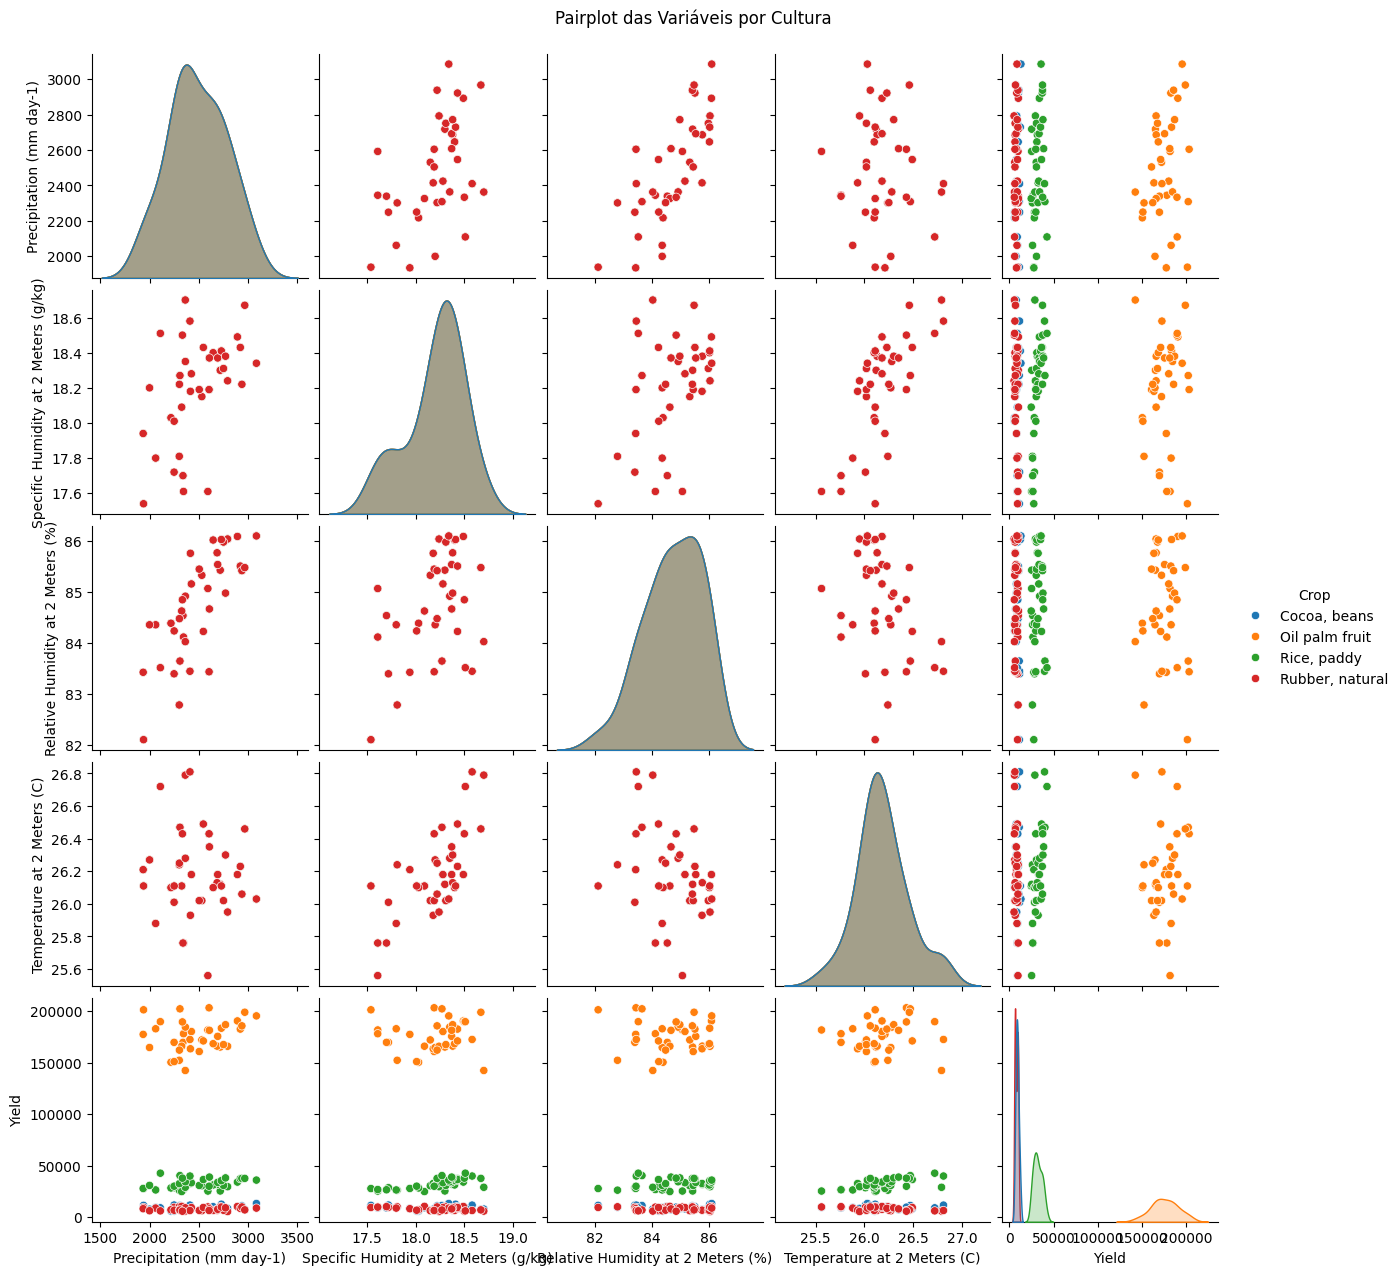

In [27]:
# == Pairplot por Cultura ==

sns.pairplot(df, hue="Crop", diag_kind="kde")
plt.suptitle("Pairplot das Variáveis por Cultura", y=1.02)
plt.show()

Análise do Pairplot
O pairplot confirma visualmente as descobertas anteriores da EDA. Nos gráficos de dispersão entre variáveis climáticas e Yield (última linha e última coluna), os pontos de cada cultura formam faixas horizontais claramente separadas:
1) Oil palm fruit concentra-se na faixa superior (~140.000 a 203.000);
2) Rice, paddy na faixa intermediária (~25.000 a 42.000) e
3) Cocoa, beans e Rubber, natural na faixa inferior (~5.000 a 13.000).

Independentemente do valor da variável climática, cada cultura permanece na sua faixa de rendimento, reforçando que o tipo de cultura é o fator determinante do Yield.

Nos gráficos entre variáveis climáticas (bloco superior esquerdo), os pontos de todas as culturas se misturam completamente, o que é coerente com a descoberta de que os dados climáticos são idênticos para as quatro culturas. Também é possível observar visualmente as correlações identificadas na matriz:

1) Precipitação e Umidade Relativa apresentam uma tendência positiva clara, assim como Umidade Específica e Temperatura;
2) As curvas de distribuição na diagonal mostram que as variáveis climáticas possuem distribuições semelhantes entre as culturas (as curvas de cada cor se sobrepõem), enquanto o Yield apresenta picos separados para cada cultura, refletindo as faixas distintas de rendimento.

#**ANÁLISE 07 - ANÁLISE POR TIPO DE CULTURA**

In [28]:
# == Estatísticas por Cultura ==

df.groupby("Crop").mean(numeric_only=True)

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
Crop,,,,,
"Cocoa, beans",2486.498974,18.203077,84.737692,26.18359,8883.128205
Oil palm fruit,2486.498974,18.203077,84.737692,26.18359,175804.692308
"Rice, paddy",2486.498974,18.203077,84.737692,26.18359,32099.666667
"Rubber, natural",2486.498974,18.203077,84.737692,26.18359,7824.897436


In [29]:
# == Métricas detalhadas do Yield por Cultura ==

df.groupby("Crop")["Yield"].agg(["mean", "median", "std", "min", "max"])

,mean,median,std,min,max
Crop,,,,,
"Cocoa, beans",8883.128205,8848.0,1745.030586,5765,13056
Oil palm fruit,175804.692308,175629.0,14919.869752,142425,203399
"Rice, paddy",32099.666667,31101.0,4789.948436,24686,42550
"Rubber, natural",7824.897436,7817.0,1600.255042,5249,10285


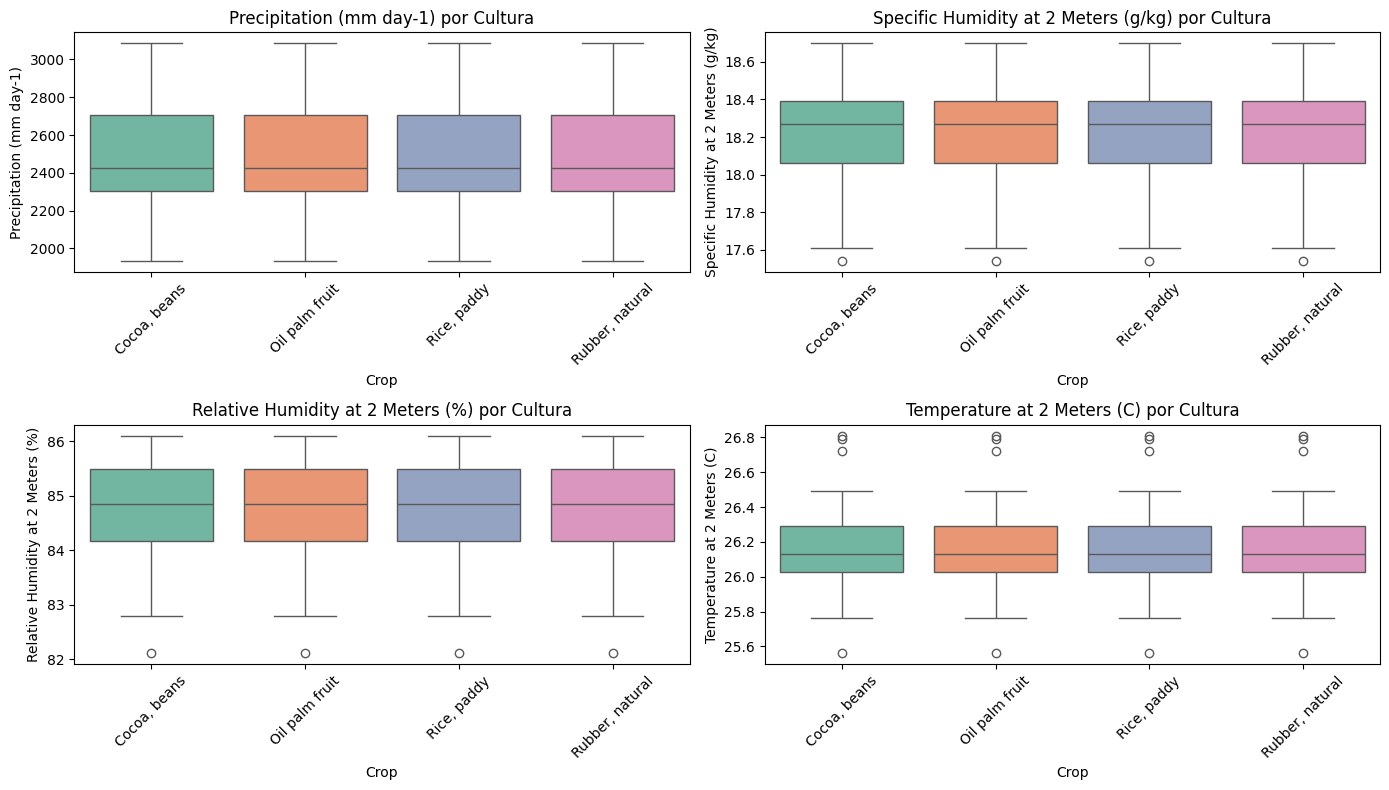

In [34]:
# == Boxplots das variáveis climáticas por Cultura ==

colunas_clima = ["Precipitation (mm day-1)", "Specific Humidity at 2 Meters (g/kg)",
                 "Relative Humidity at 2 Meters (%)", "Temperature at 2 Meters (C)"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes_flat = axes.flatten()

for i, coluna in enumerate(colunas_clima):
    sns.boxplot(data=df, x="Crop", y=coluna, hue="Crop", ax=axes_flat[i], palette="Set2", legend=False)
    axes_flat[i].set_title(f"{coluna} por Cultura")
    axes_flat[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Análise por Tipo de Cultura
As estatísticas agrupadas por cultura reforçam os achados anteriores. As médias de todas as variáveis climáticas são idênticas entre as quatro culturas, confirmando que os dados representam a mesma região geográfica sob as mesmas condições. A única variável que diferencia as culturas é o Yield, com médias que variam expressivamente: Oil palm fruit (175.805), Rice, paddy (32.100), Cocoa, beans (8.883) e Rubber, natural (7.825).
As métricas detalhadas do Yield por cultura mostram que todas as culturas possuem mediana próxima da média, indicando distribuições relativamente simétricas dentro de cada grupo. Oil palm fruit apresenta o maior desvio padrão em valor absoluto (14.920), porém o menor coeficiente de variação (8,5%), sendo a cultura mais previsível. Rubber, natural, com o maior coeficiente de variação (20,5%), é a mais imprevisível proporcionalmente.
Os boxplots das variáveis climáticas por cultura confirmam visualmente que as quatro culturas compartilham exatamente os mesmos dados climáticos — as caixas possuem formato, posição e tamanho idênticos para todas as culturas. Isso reforça a conclusão de que o tipo de cultura é o único fator diferenciador do rendimento neste dataset.

##**ANÁLISE 08 - IDENTIFICAÇÃO E TRATAMENTO DE OUTLIERS**

In [31]:
# == Identificação de Outliers pelo Método IQR ==

colunas_numericas = df.select_dtypes(include="number").columns.tolist()

for col in colunas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < limite_inferior) | (df[col] > limite_superior)).sum()
    print(f"{col}:")
    print(f"  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"  Limites: [{limite_inferior:.2f}, {limite_superior:.2f}]")
    print(f"  Outliers: {n_outliers}")
    print()

Precipitation (mm day-1):
  Q1=2302.99, Q3=2718.08, IQR=415.09
  Limites: [1680.35, 3340.72]
  Outliers: 0

Specific Humidity at 2 Meters (g/kg):
  Q1=18.03, Q3=18.40, IQR=0.37
  Limites: [17.48, 18.95]
  Outliers: 0

Relative Humidity at 2 Meters (%):
  Q1=84.12, Q3=85.51, IQR=1.39
  Limites: [82.03, 87.59]
  Outliers: 0

Temperature at 2 Meters (C):
  Q1=26.02, Q3=26.30, IQR=0.28
  Limites: [25.60, 26.72]
  Outliers: 12

Yield:
  Q1=8327.75, Q3=67518.75, IQR=59191.00
  Limites: [-80458.75, 156305.25]
  Outliers: 35



In [32]:
# == Outliers do Yield por Cultura ==

for crop in df["Crop"].unique():
    subset = df[df["Crop"] == crop]["Yield"]
    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    n_outliers = ((subset < limite_inferior) | (subset > limite_superior)).sum()
    print(f"{crop}: {n_outliers} outliers (limites: [{limite_inferior:.2f}, {limite_superior:.2f}])")

Cocoa, beans: 0 outliers (limites: [4445.50, 13201.50])
Oil palm fruit: 0 outliers (limites: [137198.75, 214048.75])
Rice, paddy: 0 outliers (limites: [16586.00, 47806.00])
Rubber, natural: 0 outliers (limites: [2086.25, 13584.25])


Identificação Quantitativa de Outliers

Nos boxplots individuais do Passo 3, observamos pontos isolados fora dos bigodes nas variáveis Temperature at 2 Meters e Yield. Esses pontos são os outliers, e o boxplot os identifica internamente usando o método IQR (Interquartile Range). A caixa do boxplot representa o intervalo entre o primeiro quartil (Q1) e o terceiro quartil (Q3) — ou seja, onde estão os 50% centrais dos dados. Os bigodes se estendem até Q1 - 1,5 × IQR e Q3 + 1,5 × IQR. Qualquer ponto além dos bigodes aparece como um ponto isolado no gráfico — esses são os outliers.

Aplicando esse mesmo cálculo de forma explícita no código, confirmamos o que o boxplot mostrou visualmente: Temperature at 2 Meters possui 12 outliers (valores acima de 26,72°C) e Yield possui 35 outliers. As demais variáveis climáticas não apresentam outliers, o que é coerente com os seus boxplots sem pontos isolados.

Porém, ao aplicar o mesmo cálculo no Yield separado por cultura, os 35 outliers desaparecem completamente — todas as culturas apresentam zero outliers quando analisadas individualmente.
Isso confirma quantitativamente o que foi observado ao longo da EDA:

os valores que parecem discrepantes no boxplot global são, na verdade, rendimentos legítimos de culturas com escalas naturalmente diferentes.

Decisão de tratamento:
Optamos por não remover nenhum registro do dataset.
Os outliers de Yield são explicados pela diferença natural entre culturas, e os outliers de Temperature representam condições climáticas reais que podem ser relevantes para a modelagem preditiva.
A remoção desses dados reduziria um dataset já pequeno (156 registros) sem justificativa técnica.

##**CONCLUSÃO DO EDA**

**Conclusão da Análise Exploratória de Dados**

Estrutura dos dados:
O dataset possui 156 registros e 6 variáveis (1 categórica e 5 numéricas), sem valores ausentes. Os dados são perfeitamente balanceados, com 39 registros para cada uma das 4 culturas: Cocoa, beans; Oil palm fruit; Rice, paddy; e Rubber, natural.

Principal descoberta:
As variáveis climáticas são idênticas para todas as culturas — os mesmos 39 registros de condições climáticas se repetem para cada cultura, variando apenas o rendimento (Yield). Isso indica que os dados representam a mesma região geográfica, e o tipo de cultura é o único fator diferenciador do rendimento.

Correlações:
Nenhuma variável climática apresenta correlação significativa com o Yield (valores próximos de zero). Entre as variáveis climáticas, destacam-se as correlações entre Precipitação e Umidade Relativa (0,75) e entre Umidade Específica e Temperatura (0,70), indicando multicolinearidade que deverá ser considerada na modelagem.

Dispersão e escalas:
As variáveis climáticas possuem baixa variação (CV entre 1,0% e 11,6%), enquanto o Yield apresenta dispersão extrema (CV = 125,4%) quando analisado globalmente. Porém, quando analisado por cultura, o coeficiente de variação cai para a faixa de 8,5% a 20,5%, confirmando que a dispersão global é causada pela diferença natural entre culturas. As variáveis estão em escalas muito diferentes (Precipitação ~2.486 vs Temperatura ~26), exigindo padronização antes da aplicação de algoritmos sensíveis a escala.
Outliers: Foram identificados outliers em Temperature (12 registros) e Yield (35 registros). Os outliers de Yield desaparecem completamente quando analisados por cultura, confirmando que são valores legítimos. Optamos por manter todos os registros no dataset.

Hipóteses para a Clusterização:
Os clusters tendem a se formar pela separação de Yield entre culturas, dado que as condições climáticas são compartilhadas. A padronização das variáveis será obrigatória para que o K-Means não seja dominado pela escala do Yield. Será importante avaliar se os clusters revelam padrões além da separação óbvia entre culturas.

Hipóteses para a Modelagem Preditiva:
A variável Crop será indispensável como feature via encoding, pois é o principal fator explicativo do rendimento. Os modelos devem ter maior facilidade em prever o rendimento de Oil palm fruit (CV = 8,5%) e maior dificuldade com Rubber, natural (CV = 20,5%). A multicolinearidade entre variáveis climáticas pode afetar a Regressão Linear, mas não modelos baseados em árvores. O tamanho reduzido do dataset (156 registros) exigirá o uso de cross-validation para uma avaliação robusta dos modelos.

#**II. CLUSTERIZAÇÃO**

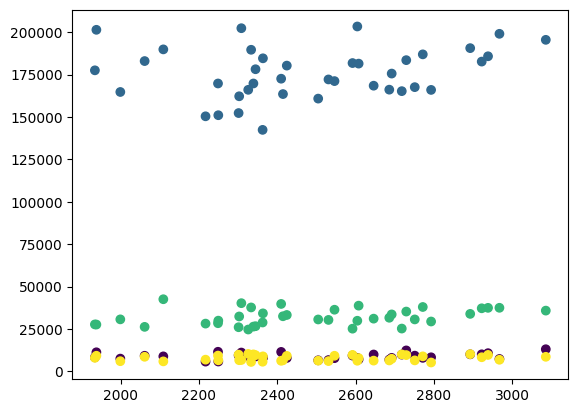

In [8]:
# Plotando os dados
plt.scatter(x=df["Precipitation (mm day-1)"], y=df["Yield"], c=df["Crop"].astype("category").cat.codes)
plt.show()

O gráfico de dispersão mostra a relação entre Precipitação (eixo X) e Yield (eixo Y), com os pontos coloridos por tipo de cultura. É possível identificar visualmente quatro faixas horizontais, que correspondem às quatro culturas do dataset:

1) Oil palm fruit se destaca isolada no topo do gráfico, com rendimentos muito superiores às demais (~140.000 a 203.000);
2) Rice paddy ocupa uma faixa intermediária (~25.000 a 42.000), claramente separada das demais;
3) Na parte inferior, Cocoa beans e Rubber natural aparecem sobrepostas, com valores de Yield muito próximos (~5.000 a 13.000), o que dificulta a distinção visual entre elas.

Esse padrão confirma o que as estatísticas descritivas e o boxplot por cultura já haviam mostrado na EDA: o Yield é determinado principalmente pelo tipo de cultura, e não pelas condições climáticas.

As faixas horizontais indicam que, para cada cultura, a variação da Precipitação no eixo X não altera significativamente o rendimento, reforçando a ausência de correlação entre variáveis climáticas e Yield identificada na análise de correlação.

Do ponto de vista da clusterização, esse gráfico antecipa que o algoritmo conseguirá separar com facilidade os grupos de Oil palm fruit e Rice paddy, mas terá dificuldade em distinguir Cocoa beans de Rubber natural devido à sobreposição dos seus rendimentos.

#**A - PRÉ-PROCESSAMENTO DOS DADOS: ENCONDING**

Antes de aplicar os algoritmos de clusterização, é necessário preparar os dados. O primeiro passo é o encoding da variável categórica Crop. Algoritmos como K-Means e DBSCAN utilizam distância euclidiana para calcular a similaridade entre os registros, e essa operação matemática funciona apenas com valores numéricos. Como a coluna Crop contém texto (Cocoa beans, Oil palm fruit, Rice paddy, Rubber natural), precisamos transformá-la em colunas numéricas binárias (0 ou 1) por meio da técnica de One-Hot Encoding. Essa transformação é especialmente importante porque a EDA mostrou que Crop é o fator determinante do Yield — sem incluí-la na clusterização, o algoritmo perderia a informação mais relevante para diferenciar os registros.

In [17]:
df_encoded = pd.get_dummies(df, columns=["Crop"], drop_first=True)
df_encoded

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield,Crop_Oil palm fruit,"Crop_Rice, paddy","Crop_Rubber, natural"
0,2248.92,17.72,83.40,26.01,11560,False,False,False
1,1938.42,17.54,82.11,26.11,11253,False,False,False
2,2301.54,17.81,82.79,26.24,9456,False,False,False
3,2592.35,17.61,85.07,25.56,9321,False,False,False
4,2344.72,17.61,84.12,25.76,8800,False,False,False
...,...,...,...,...,...,...,...,...
151,2308.51,18.27,83.65,26.47,6721,False,False,True
152,2410.13,18.58,83.45,26.81,6248,False,False,True
153,2967.41,18.67,85.48,26.46,6842,False,False,True
154,2333.46,18.50,84.85,26.43,5571,False,False,True


In [18]:
df_encoded.columns.tolist()

['Precipitation (mm day-1)',
 'Specific Humidity at 2 Meters (g/kg)',
 'Relative Humidity at 2 Meters (%)',
 'Temperature at 2 Meters (C)',
 'Yield',
 'Crop_Oil palm fruit',
 'Crop_Rice, paddy',
 'Crop_Rubber, natural']

A coluna categórica Crop foi transformada em colunas binárias (0 e 1) por meio da técnica One-Hot Encoding. Essa transformação é necessária porque os algoritmos de clusterização (K-Means e DBSCAN) utilizam distância euclidiana para medir a similaridade entre registros, e essa operação só funciona com valores numéricos. Não seria adequado substituir as culturas por números simples (1, 2, 3, 4) porque o algoritmo interpretaria uma ordem e uma magnitude que não existem entre categorias — por exemplo, entenderia que Rubber (4) é "mais distante" de Cocoa (1) do que Oil palm (2), o que não faz sentido. O One-Hot Encoding evita esse problema criando uma dimensão independente para cada cultura. Foi utilizado o parâmetro drop_first=True, que remove uma das colunas para evitar redundância: Cocoa beans ficou como categoria de referência, representada quando as três colunas restantes (Oil palm fruit, Rice paddy, Rubber natural) são todas iguais a 0.

##**B - PRÉ-PROCESSAMENTO DOS DADOS: PADRONIZAÇÃO**

O próximo passo é padronizar os dados, porque as variáveis estão em escalas muito diferentes, o que pode gerar resultados discrepantes nos algoritmos de clusterização.
Conforme identificado na EDA:

1) o Yield tem valores na casa das dezenas de milhares (~56.000);
2) a Precipitação na casa dos milhares (~2.486);
3) enquanto a Temperatura fica na casa das dezenas (~26).

Como o K-Means utiliza distância euclidiana, variáveis com valores maiores dominariam o cálculo da distância, como se as variáveis de menor escala não existissem. A padronização com StandardScaler transforma todas as variáveis para a mesma escala (média=0 e desvio padrão=1), garantindo que cada uma contribua igualmente para a formação dos clusters.

In [20]:
scaler = StandardScaler()
df_encoded_standarded = scaler.fit_transform(df_encoded)

In [21]:
df_encoded_standarded

array([[-0.82341547, -1.64884495, -1.34708396, ..., -0.57735027,
        -0.57735027, -0.57735027],
       [-1.89956502, -2.26322349, -2.64614077, ..., -0.57735027,
        -0.57735027, -0.57735027],
       [-0.64104192, -1.34165569, -1.96136664, ..., -0.57735027,
        -0.57735027, -0.57735027],
       ...,
       [ 1.66677031,  1.59370842,  0.74751928, ..., -0.57735027,
        -0.57735027,  1.73205081],
       [-0.53041167,  1.01346203,  0.11309618, ..., -0.57735027,
        -0.57735027,  1.73205081],
       [-1.30718022,  1.04759417, -1.22624146, ..., -0.57735027,
        -0.57735027,  1.73205081]])

Agora que o processo de padronização está completo, o StandardScale() transformou os dados de maneira que:

1)Todos os valores agora giram em torno de 0 (positivos e negativos);       
2) Não tem mais valores na casa dos milhares ou dezenas de milhares — tudo está na mesma escala;

Com esse resultado, agora, estamos prontos para iniciar o processo específico de clusterização dos dados.

#**C - PROCESSAMENTO: ALGORITMO K-MEANS e DBSCAN**

Antes de aplicar o K-Means, é necessário entender qual é o número adequado de Clusters (K) para o projeto. Nós vamos, então, adotar os seguintes métodos para tentar justificar a escolha:

1) Método do cotovelo — gráfico de inércia para K de 1 a 10;
2) Método da silhueta — gráfico de score para K de 2 a 10;

A partir do resultados dos gráficos criados, vamos definir o K para só então podermos aplicar K-Means e DBSCAN com o K escolhido.

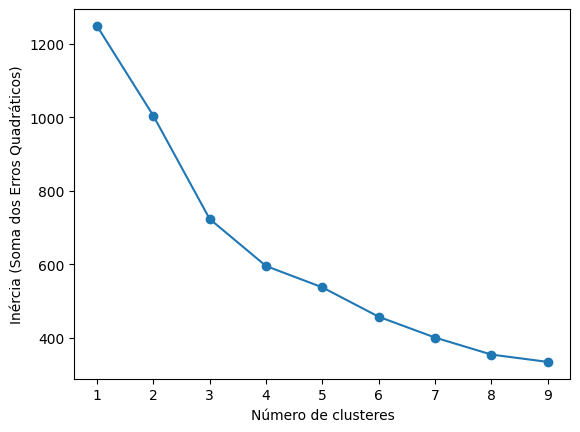

In [22]:
#Aplicação do Método do Cotovelo

k = list(range(1, 10))
sse = []
for i in k:
  kmeans = KMeans(n_clusters=i, random_state=0)
  kmeans.fit(df_encoded_standarded)
  sse.append(kmeans.inertia_)
plt.plot(k, sse, "-o")
plt.xlabel("Número de clusteres")
plt.ylabel("Inércia (Soma dos Erros Quadráticos)")
plt.show()

O gráfico do método do cotovelo mostra a inércia (soma dos erros quadráticos internos) para cada valor de K. A curva apresenta uma queda acentuada de K=1 até K=4, indicando que cada novo cluster melhora significativamente a compactação dos grupos.

A partir de K=4, a curva se estabiliza — adicionar mais clusters traz ganho marginal. O ponto de inflexão ("cotovelo") aparece em K=4, sugerindo esse como o número ideal de clusters.

Esse resultado é coerente com os achados da EDA, onde identificamos 4 culturas com faixas de rendimento distintas.

Agora, vamos utilizar o método da silhueta para verificar se esse achado se confirma.


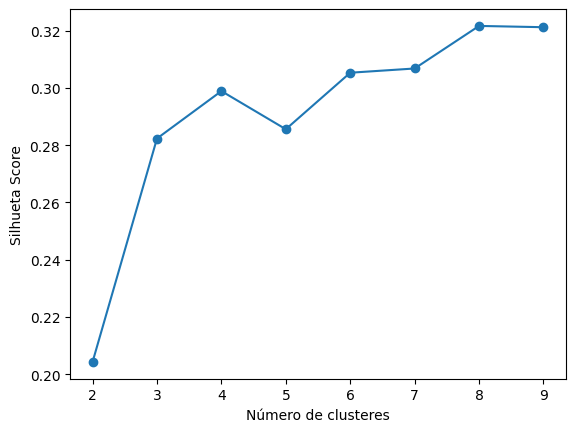

In [26]:
#Aplicação do método silhueta

k = list(range(2, 10))
s_scores = []
for i in k:
  kmeans = KMeans(n_clusters=i, random_state=0)
  labels = kmeans.fit_predict(df_encoded_standarded)
  s_scores.append(silhouette_score(df_encoded_standarded, labels))
plt.plot(k, s_scores, "-o")
plt.xlabel("Número de clusteres")
plt.ylabel("Silhueta Score")
plt.show()

O gráfico de silhueta mostrou resultado divergente apontando para um resultado melhor se fossem utilizados 3 ou 6 clusters.

No caso desse tipo de divergência, devemos tomar a decisão que faz mais sentido para o negócio, com os achados do EDA e com o objetivo que se busca com a clusterização. Considerando esses elementos poderíamos fazer a seguintes ponderações:

1) K=3: Juntaria Cocoa beans e Rubber num único cluster, já que a EDA mostrou que possuem rendimentos muito próximos (~8.883 e ~7.825 respectivamente). Embora faça sentido numericamente, perdemos a distinção entre duas culturas diferentes que a fazenda produz e gerencia separadamente;
2) K=4: Um cluster por cultura. A EDA mostrou 4 faixas de rendimento distintas
3) K=6: Quebraria alguma cultura em sub-clusters. Com apenas 39 registros por cultura, ficaria com grupos pequenos.

Em função disso, entendemos que, de acordo com os achados do EDA e em consonância com a natureza do negócio analisado e os objetivos que buscamos com a clusterização, que o melhor seria utilizar K=4. Esse será o valor utilizado nos próximos passos da clusterização.



In [28]:
# Processamendo do K-Means com K=4

km = KMeans(n_clusters=4, random_state=42)
c_km = km.fit_predict(df_encoded_standarded)
df["label_kmeans"] = c_km

df.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield,label_kmeans
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560,1
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253,1
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456,1
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321,2
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800,1


In [31]:
db = DBSCAN(eps=1.5)
c_db = db.fit_predict(df_encoded_standarded)
df["label_dbscan"] = c_db

df.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield,label_kmeans,label_dbscan
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560,1,0
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253,1,-1
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456,1,0
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321,2,0
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800,1,0


In [32]:
df["label_dbscan"].value_counts()

,count
label_dbscan,
0,36
1,36
2,36
3,36
-1,12


O resultado utilizando eps=1,5 se mostrou adequado e coerente com os resultados do EDA, considerando que, no EDA, foram identificados exatamente 12 outliers de Temperatura. Isso sugere que a parametrização do DBSCAN está adequada para o dataset utilizado.

Agora, vamos visualizar os resultados em subplots para comparar os clusters identificados pelo K-MEANS e pelo DBSCAN.

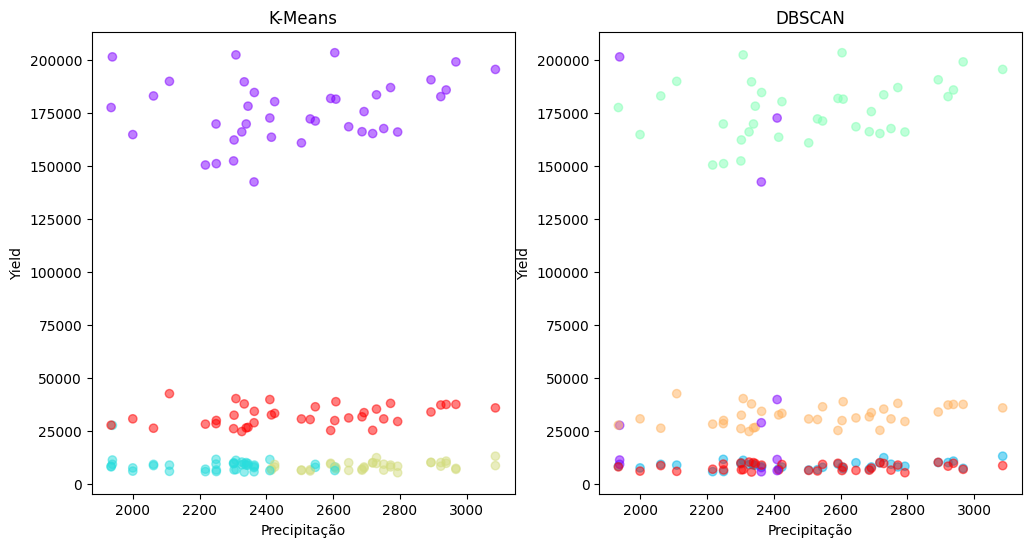

In [33]:
# Visualização dos resultados comparados

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(df["Precipitation (mm day-1)"],     # Eixo X
         df["Yield"],                          # Eixo Y
         c=df["label_kmeans"],
         alpha=0.5,                            # Transparência dos pontos
        cmap="rainbow")                       # Paleta de cores
plt.xlabel("Precipitação")
plt.ylabel("Yield")
plt.title("K-Means")

plt.subplot(1, 2, 2)
plt.scatter(df["Precipitation (mm day-1)"],     # Eixo X
         df["Yield"],                          # Eixo Y
         c=df["label_dbscan"],
         alpha=0.5,                            # Transparência dos pontos
        cmap="rainbow")                       # Paleta de cores
plt.xlabel("Precipitação")
plt.ylabel("Yield")
plt.title("DBSCAN")

plt.show()

À primeira vista, a clusterização confirmou os padrões já identificados na EDA, o que valida a robustez desses achados. No entanto, a visualização com apenas duas variáveis (Precipitação × Yield) limita a análise pelas seguintes razões:

1) DBSCAN identificou outliers em lilás que estão espalhados pelo gráfico. Como algumas cores se misturam é difícil contar, mas parecem ser 12;
2) Tanto o K-Means como o DBSCAN conseguem diferenciar bem dois grupos, mas o DBSCAN identifica 03 outliers num grupo e dois no outro e o K-MEANS separa os dois grupos sem outliers;
3) os dois grupos estão separados sendo que um bem em cima e outro um pouco acima dos dois grupos que estão abaixo bem misturados;
4) os dois grupos de baixo nem K-MEANS nem DBSCAN conseguiram diferenciar adequadamente.

Esse resultado está condizente com o gráfico de dispersão que já tínhamos feito, no qual identificamos:

1) Oil palm fruit se destaca isolada no topo do gráfico, com rendimentos muito superiores às demais (~140.000 a 203.000);
2) Rice paddy ocupa uma faixa intermediária (~25.000 a 42.000), claramente separada das demais;
3) Na parte inferior, Cocoa beans e Rubber natural aparecem sobrepostas, com valores de Yield muito próximos (~5.000 a 13.000), o que dificulta a distinção visual entre elas.

Na prática, portanto, parece que a clusterização apenas mostrou de outra forma os mesmos achados que já tínhamos.

Porém, dois pontos que agregam informação nova:

1) Os outliers do DBSCAN são informação nova. A EDA identificou outliers pelo método IQR (estatístico), o DBSCAN identificou pela densidade multidimensional (considerando todas as 8 variáveis ao mesmo tempo). Vale investigar quem são esses 12 outliers — de qual cultura, com quais condições climáticas;
2) Estamos analisando somente 2 das 8 dimensões. O gráfico usa Precipitação × Yield, mas o algoritmo usou todas as 8 variáveis padronizadas.

Conclusão: O PCA pode revelar separações que esse gráfico 2D não mostra

#**D - REDUÇÃO DAS DIMENSÕES COM PCA **

O PCA (Principal Component Analysis) é uma técnica de redução da dimensionalidade que transforma um conjunto de variáveis possivelmente correlacionadas em um novo conjunto de variáveis não correlacionadas, chamadas componentes principais. Conforme identificamos na análise anterior, o gráfico de Precipitação × Yield usava apenas 2 das 8 variáveis, descartando a informação das outras 6. O PCA resolve isso condensando as 8 variáveis em 2 componentes que preservam a maior quantidade possível de informação. Além disso, na EDA identificamos correlações entre variáveis climáticas (Precipitação × Umidade Relativa = 0,75), e o PCA aproveita essas correlações para compactar a informação de forma eficiente.

Portanto, vamos realizar agora o procedimento do PCA na base para avaliar se ele revela novos achados.

In [35]:
# Aplicar PCA para reduzir a dimensionalidade antes do treinamento
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_encoded_standarded)
print(f"Variância explicada: {pca.explained_variance_ratio_}")
print(f"Total: {sum(pca.explained_variance_ratio_):.2%}")

Variância explicada: [0.2810829  0.26742826]
Total: 54.85%


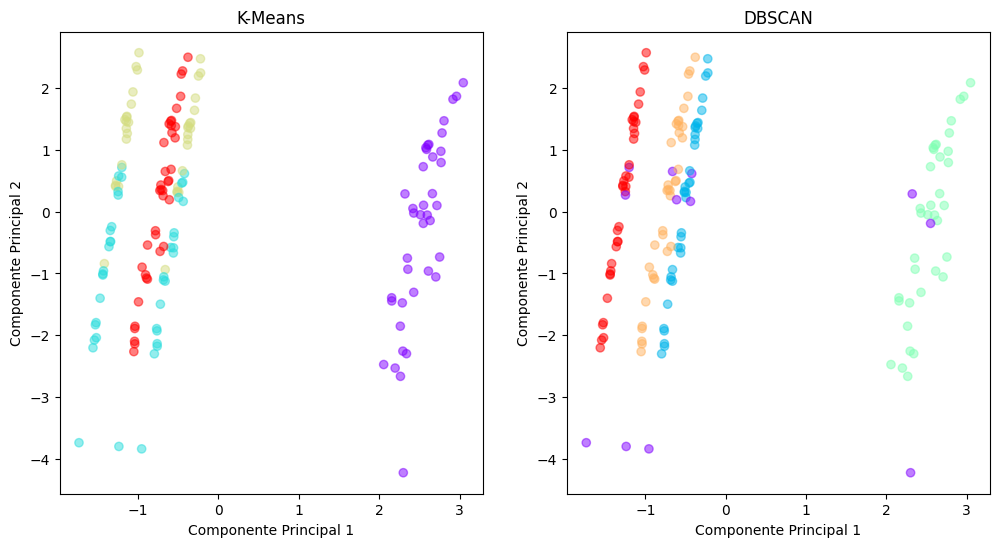

In [36]:
# Visualização dos resultados comparados

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(pca_result[:, 0],        # Eixo X
            pca_result[:, 1],        # Eixo Y
            c=df["label_kmeans"],
            alpha=0.5,               # Transparência dos pontos
            cmap="rainbow")          # Paleta de cores
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("K-Means")

plt.subplot(1, 2, 2)
plt.scatter(pca_result[:, 0],        # Eixo X
            pca_result[:, 1],        # Eixo Y
            c=df["label_dbscan"],
            alpha=0.5,               # Transparência dos pontos
            cmap="rainbow")          # Paleta de cores
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("DBSCAN")

plt.show()

A intuição sobre o PCA se mostrou justificada: o PCA revelou melhor separação que o gráfico anterior de Precipitação × Yield — mesmo preservando só 54,85% da variância.
Isso significa que as outras variáveis (que o gráfico anterior ignorava) contribuem para separar os grupos.
No caso específico do K-Means, ele misturou os dois grupos de baixo: isso não é necessariamente uma falha do K-Means, dado que ele foi configurado com K=4, então ele forçou 4 clusters. Pode ser que ele tenha separado Cocoa e Rubber por outras variáveis que não aparecem visualmente no PCA 2D.
O DBSCAN parece ter tido um melhor resultado com PCA, pois, agora, é possível, visualmente, diferenciar, claramente, 04 grupos e os outliers ficam fáceis de ser identificados.

In [37]:
# Interpretação dos clusters
df.groupby("label_kmeans").mean(numeric_only=True)

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield,label_dbscan
label_kmeans,,,,,,
0,2486.498974,18.203077,84.737692,26.183590,175804.692308,0.846154
1,2257.198049,18.096098,83.902195,26.257805,8804.902439,1.073171
2,2719.479474,18.301053,85.570000,26.101579,8374.500000,1.500000
3,2500.922105,18.220526,84.806842,26.185526,32217.578947,1.842105


In [38]:
pd.crosstab(df["Crop"], df["label_kmeans"])

label_kmeans,0,1,2,3
Crop,,,,
"Cocoa, beans",0,20,19,0
Oil palm fruit,39,0,0,0
"Rice, paddy",0,1,0,38
"Rubber, natural",0,20,19,0


A tabulação cruzada entre culturas e clusters do K-Means revelou achados importantes sobre a capacidade do algoritmo de diferenciar as culturas:

1) O Cluster 0 capturou exclusivamente os 39 registros de Oil palm fruit, demonstrando separação perfeita;
2) O Cluster 3 concentrou 38 dos 39 registros de Rice paddy, com apenas 1 registro classificado no Cluster 1 — uma separação quase perfeita.

Esses resultados eram esperados, dado que a EDA mostrou que Oil palm fruit e Rice paddy possuem faixas de Yield claramente distintas das demais.

Os Clusters 1 e 2, porém, revelam a principal limitação: ambos contêm quantidades praticamente iguais de Cocoa beans e Rubber natural (20+20 e 19+19, respectivamente).

Isso significa que o K-Means não separou essas duas culturas — ele dividiu os registros de ambas ao meio, provavelmente com base em diferenças de Precipitação (2.257 vs 2.719 entre os dois clusters), e não pelo tipo de cultura.
Esse resultado confirma a hipótese levantada na EDA:

1) como as variáveis climáticas são compartilhadas entre todas as culturas e os rendimentos de Cocoa beans (~8.883) e
2) Rubber natural (~7.825) são muito próximos, o algoritmo não dispõe de informação suficiente para distingui-las.

A clusterização confirma, portanto, que a separação entre essas duas culturas depende exclusivamente da variável Crop — algo que apenas o conhecimento do negócio pode fornecer.

In [39]:
pd.crosstab(df["Crop"], df["label_dbscan"])

label_dbscan,-1,0,1,2,3
Crop,,,,,
"Cocoa, beans",3,36,0,0,0
Oil palm fruit,3,0,36,0,0
"Rice, paddy",3,0,0,36,0
"Rubber, natural",3,0,0,0,36


In [40]:
df[df["label_dbscan"] == -1]

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield,label_kmeans,label_dbscan
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253,1,-1
17,"Cocoa, beans",2362.80,18.70,84.03,26.79,7663,1,-1
35,"Cocoa, beans",2410.13,18.58,83.45,26.81,11487,1,-1
40,Oil palm fruit,1938.42,17.54,82.11,26.11,201436,0,-1
56,Oil palm fruit,2362.80,18.70,84.03,26.79,142425,0,-1
74,Oil palm fruit,2410.13,18.58,83.45,26.81,172601,0,-1
79,"Rice, paddy",1938.42,17.54,82.11,26.11,27619,1,-1
95,"Rice, paddy",2362.80,18.70,84.03,26.79,28829,3,-1
113,"Rice, paddy",2410.13,18.58,83.45,26.81,39775,3,-1
118,"Rubber, natural",1938.42,17.54,82.11,26.11,9223,1,-1


A tabulação cruzada do DBSCAN revelou um resultado superior ao K-Means: o algoritmo conseguiu separar perfeitamente as 4 culturas em 4 clusters distintos, com 36 registros cada, incluindo a separação entre Cocoa beans e Rubber natural que o K-Means não conseguiu realizar.
Além disso, o DBSCAN identificou 12 outliers, distribuídos igualmente entre as culturas (3 de cada). A análise detalhada desses outliers revelou um padrão que nem a EDA nem o K-Means haviam identificado: os 12 outliers correspondem a 3 condições climáticas atípicas, cada uma compartilhada pelas 4 culturas. As três condições são:

Precipitação=1938.42, Umidade Específica=17.54, Temperatura=26.11
Precipitação=2362.80, Umidade Específica=18.70, Temperatura=26.79
Precipitação=2410.13, Umidade Específica=18.58, Temperatura=26.81

Como a EDA já havia demonstrado que os dados climáticos são compartilhados entre as culturas, esse resultado é coerente: o DBSCAN detectou 3 registros climáticos que se afastam do padrão geral do dataset. O primeiro grupo em particular apresenta Precipitação de 1938.42, significativamente abaixo da média (~2.486), representando uma condição de menor pluviosidade.
Esse é um achado genuinamente novo da clusterização: enquanto a EDA identificou outliers por variável isolada (método IQR), o DBSCAN os identificou considerando todas as 8 variáveis simultaneamente, revelando que são condições climáticas completas que se afastam do comportamento típico da região.

##**Conclusão da Clusterização**

A clusterização aplicada ao dataset crop_yield.csv confirmou e aprofundou os achados da Análise Exploratória de Dados, além de revelar informações novas que a EDA não havia capturado.

- K-Means (K=4): O algoritmo separou com perfeição Oil palm fruit e quase perfeitamente Rice paddy, mas não conseguiu distinguir Cocoa beans de Rubber natural. Os clusters 1 e 2 dividiram os registros dessas duas culturas ao meio, agrupando-os por variações na Precipitação e não pelo tipo de cultura. Isso confirma a limitação identificada na EDA: com rendimentos muito próximos (~8.883 vs ~7.825) e variáveis climáticas compartilhadas, o algoritmo não dispõe de informação numérica suficiente para separá-las.

- DBSCAN (eps=1.5, min_samples=5): Apresentou resultado superior, separando perfeitamente as 4 culturas em clusters de 36 registros cada. Além disso, identificou 12 outliers que representam 3 condições climáticas atípicas compartilhadas pelas 4 culturas — um achado inédito que a EDA e o K-Means não revelaram.

- PCA: A redução para 2 componentes preservou 54,85% da variância total, abaixo do ideal de 80%. Ainda assim, permitiu uma visualização dos clusters significativamente melhor do que o gráfico de Precipitação × Yield, confirmando que as demais variáveis contribuem para a separação dos grupos.

**Pontos fortes da análise:**

1) A clusterização validou, com métodos não supervisionados, os padrões identificados na EDA — confirmando que o tipo de cultura é o fator determinante do rendimento;
2) O DBSCAN revelou condições climáticas atípicas que merecem atenção na gestão da fazenda;
3) A comparação entre dois algoritmos distintos (baseado em distância vs baseado em densidade) enriqueceu a análise;

**Limitações identificadas:**

1) O K-Means não consegue separar culturas com rendimentos muito próximos quando as variáveis climáticas são compartilhadas;
2) O PCA preservou pouco mais da metade da variância, limitando a visualização;
3) O dataset pequeno (156 registros, 39 por cultura) restringe a complexidade das análises possíveis.

**Implicações para a Tarefa 3 — Regressão Supervisionada**

Os achados da clusterização trazem diretrizes importantes para a construção dos modelos preditivos de regressão:

1) A variável Crop é indispensável como feature. Tanto a EDA quanto a clusterização demonstraram que o rendimento é determinado primariamente pelo tipo de cultura. Modelos que não incluírem Crop como variável preditora terão desempenho significativamente inferior;
2) A padronização será necessária para algoritmos sensíveis à escala (como SVR e KNN Regressor), pelo mesmo motivo que foi obrigatória na clusterização: as variáveis estão em escalas muito diferentes;
3) Modelos baseados em árvore podem ter vantagem. O K-Means (baseado em distância linear) não conseguiu separar Cocoa de Rubber, mas modelos como Decision Tree, Random Forest e Gradient Boosting trabalham com divisões condicionais e podem capturar melhor essas diferenças sutis;
4) Os 12 outliers identificados pelo DBSCAN merecem atenção. Essas condições climáticas atípicas podem gerar erros maiores nos modelos de regressão. A análise de resíduos poderá confirmar se os modelos erram mais nesses registros específicos;
5) Espera-se que os modelos prevejam melhor Oil palm fruit (CV=8,5%, mais previsível) do que Rubber natural (CV=20,5%, mais imprevisível), conforme já indicado na EDA e reforçado pela dificuldade de separação na clusterização.

#**III - REGRESSÃO SUPERVISIONADA**

Chegamos à parte final do projeto, na qual, devemos:

"Treinar 5 modelos diferentes para prever o rendimento da safra, usando algoritmos distintos. Dividir dados em treino e teste. Treinar e avaliar com métricas de regressão (R², MAE, MSE, RMSE). Comparar desempenho dos 5 modelos. Identificar o melhor modelo e justificar."

A primeira etapa consiste na preparação dos dados e padronização. Apesar de já termos feito o encoding para a clusterização, para a regressão o ideal é partir do DataFrame original e refazer o encoding, para ter um fluxo limpo sem as colunas de clusterização.

Em relação às features, foram removidas as variáveis Umidade Específica, Umidade Relativa e Temperatura, pois a EDA demonstrou que não possuem correlação com o Yield. Precipitação foi mantida por ser a variável climática com maior variação (CV=11,6%), o que a torna a mais promissora entre as climáticas para contribuir com os modelos.

As colunas de Crop (via One-Hot Encoding) são as features mais importantes, dado que a EDA e a clusterização confirmaram que o tipo de cultura é o fator determinante do rendimento.

A padronização foi aplicada apenas para o SVR (Support Vector Regression), que é o único dos 5 algoritmos sensível à escala dos dados por utilizar distância no seu cálculo. Para os demais modelos (Linear Regression, Decision Tree, Random Forest e XGBoost), os dados são utilizados na escala original.

##**I - PREPARAÇÃO DOS DADOS**

In [41]:
# Preparação dos dados
df_encoded_for_regression = pd.get_dummies(df, columns=["Crop"], drop_first=True)

X = df_encoded_for_regression.drop(columns=["Yield", "Specific Humidity at 2 Meters (g/kg)", "Relative Humidity at 2 Meters (%)", "Temperature at 2 Meters (C)", "label_kmeans", "label_dbscan"])
y = df_encoded_for_regression["Yield"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)


In [42]:
 X_train.shape

(124, 4)

In [43]:
X_test.shape


(32, 4)

In [44]:
# Padronização
scaler_for_regression = StandardScaler()
X_train_scaled = scaler_for_regression.fit_transform(X_train)
X_test_scaled = scaler_for_regression.transform(X_test)

In [48]:
X_train_scaled

array([[-0.40371341,  1.660595  , -0.54006172, -0.60219379],
       [-0.60995016, -0.60219379, -0.54006172,  1.660595  ],
       [-0.53029678, -0.60219379, -0.54006172,  1.660595  ],
       [-0.79370466, -0.60219379, -0.54006172,  1.660595  ],
       [-0.90604697, -0.60219379, -0.54006172,  1.660595  ],
       [ 2.08929961,  1.660595  , -0.54006172, -0.60219379],
       [ 0.38782055,  1.660595  , -0.54006172, -0.60219379],
       [ 0.86084442, -0.60219379, -0.54006172, -0.60219379],
       [-0.40371341, -0.60219379, -0.54006172,  1.660595  ],
       [-1.86705989, -0.60219379,  1.8516402 , -0.60219379],
       [ 0.71143398, -0.60219379, -0.54006172,  1.660595  ],
       [ 1.68110188, -0.60219379, -0.54006172, -0.60219379],
       [ 1.68110188,  1.660595  , -0.54006172, -0.60219379],
       [ 0.73260592, -0.60219379, -0.54006172, -0.60219379],
       [ 1.07952917, -0.60219379, -0.54006172,  1.660595  ],
       [-1.44227631, -0.60219379,  1.8516402 , -0.60219379],
       [-0.79370466, -0.

In [49]:
X_test_scaled

array([[ 1.07952917, -0.60219379,  1.8516402 , -0.60219379],
       [ 1.58069034,  1.660595  , -0.54006172, -0.60219379],
       [-0.46605684, -0.60219379,  1.8516402 , -0.60219379],
       [-0.50488355,  1.660595  , -0.54006172, -0.60219379],
       [ 1.68110188, -0.60219379,  1.8516402 , -0.60219379],
       [ 0.22913446, -0.60219379, -0.54006172, -0.60219379],
       [-1.65634048, -0.60219379,  1.8516402 , -0.60219379],
       [-0.22444157, -0.60219379, -0.54006172,  1.660595  ],
       [-0.22444157, -0.60219379,  1.8516402 , -0.60219379],
       [ 0.73260592, -0.60219379, -0.54006172,  1.660595  ],
       [ 0.93570481, -0.60219379, -0.54006172, -0.60219379],
       [ 0.17613565, -0.60219379,  1.8516402 , -0.60219379],
       [-0.22444157, -0.60219379, -0.54006172, -0.60219379],
       [-1.44227631, -0.60219379, -0.54006172,  1.660595  ],
       [-0.40085141, -0.60219379, -0.54006172, -0.60219379],
       [ 1.58069034, -0.60219379, -0.54006172, -0.60219379],
       [-0.61495005, -0.

##**B - TREINAMENTO DOS ALGORITMOS**

Agora temos tudo pronto para treinar os modelos. Nós optamos em treinar cinco modelos:

1) Regressão Linear Múltipla

2) Decision Tree Regressor (Árvore de Decisão)

3) Random Forest Regressor (Floresta Aleatória)

4) XGBoost (Gradient Boosting)

5) SVR (Support Vector Regression)

### 1\. Regressão Linear Múltipla

**Como funciona:** Encontra a melhor reta (ou hiperplano, com múltiplas variáveis) que minimiza a soma dos quadrados das diferenças entre os valores previstos e reais. É o modelo mais simples — cada variável tem um coeficiente (peso) que indica quanto ela influencia o Yield.

**Fórmula:** `y = b0 + b1*x1 + b2*x2 + ... + bn*xn`

**Por que incluir:** É o baseline — o modelo mais simples possível. Se modelos mais complexos não forem significativamente melhores, a regressão linear é preferível por ser mais interpretável.

**Limitação para o nosso dataset:** Assume relação linear entre features e Yield. A EDA mostrou que a relação é dominada por Crop (categórica), então a "linearidade" vem basicamente do encoding binário.

**Precisa de padronização?** Não é obrigatório (não usa distância), mas facilita a interpretação dos coeficientes.

In [50]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)


### 2\. Decision Tree Regressor (Árvore de Decisão)

**Como funciona:** Cria uma estrutura de "perguntas" em sequência (como um fluxograma). Em cada nó, o algoritmo pergunta algo como "Crop_Oil palm = 1?" ou "Precipitação > 2500?". Dependendo da resposta, segue para uma ramificação diferente. A folha final contém a média dos valores de Yield dos registros que chegaram ali.

**Por que incluir:** Trabalha com divisões condicionais — pode capturar que "se Crop = Oil palm, Yield alto; senão, Yield baixo" de forma natural. A clusterização mostrou que o K-Means (baseado em distância) teve dificuldade com Cocoa vs Rubber, mas árvores usam lógica condicional, que é diferente.

**Limitação:** Pode sofrer overfitting facilmente — a árvore pode decorar os dados de treino em vez de aprender padrões generalizáveis.

**Precisa de padronização?** Não. Árvores de decisão não usam distância.

In [54]:
modelo_DTR = DecisionTreeRegressor(max_depth=5, random_state=42)
modelo_DTR.fit(X_train, y_train)
y_pred_DTR = modelo_DTR.predict(X_test)

### 3\. Random Forest Regressor (Floresta Aleatória)

**Como funciona:** Cria **muitas** árvores de decisão (ex: 100), cada uma treinada com uma amostra aleatória dos dados e um subconjunto aleatório das features. A previsão final é a **média** das previsões de todas as árvores.

**Por que incluir:** Corrige a principal fraqueza da Árvore de Decisão (overfitting) ao combinar muitas árvores diversas. É geralmente um dos algoritmos com melhor desempenho "out of the box".

**Precisa de padronização?** Não. Baseada em árvores.

In [55]:
modelo_RFR = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
modelo_RFR.fit(X_train, y_train)
y_pred_RFR = modelo_RFR.predict(X_test)

### 4\. XGBoost (Gradient Boosting)

**Como funciona:** Também usa múltiplas árvores, mas de forma

**sequencial**: a primeira árvore faz previsões, a segunda árvore tenta corrigir os **erros** da primeira, a terceira corrige os erros da segunda, e assim por diante. Cada árvore nova foca no que as anteriores erraram.

**Por que incluir:** É o algoritmo que vence a maioria das competições de ML. O material da FIAP dedica uma seção inteira a ele. Tem regularização embutida (L1 e L2) para controlar overfitting.

**Precisa de padronização?** Não. Baseado em árvores.

In [56]:
modelo_XGBR = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
modelo_XGBR.fit(X_train, y_train)
y_pred_XGBR = modelo_XGBR.predict(X_test)

### 5\. SVR (Support Vector Regression)

**Como funciona:** Tenta encontrar uma linha (ou curva) que se ajuste aos dados mantendo a maioria dos pontos dentro de uma "margem de erro" definida. Em vez de minimizar todo o erro, o SVR ignora erros pequenos (dentro da margem) e foca nos erros grandes.

**Por que incluir:** Abordagem completamente diferente dos outros 4 — traz diversidade. Funciona bem com datasets pequenos (156 registros). Pode usar funções não-lineares (kernel) para capturar relações complexas.

**Precisa de padronização?** SIM, obrigatório. O SVR é muito sensível à escala das variáveis (usa distância no espaço de features).

In [59]:
modelo_SVR = SVR(kernel="rbf", C=1.0)
modelo_SVR.fit(X_train_scaled, y_train)
y_pred_SVR = modelo_SVR.predict(X_test_scaled)

##**C - AVALIAÇÃO DOS ALGORITMOS**

In [60]:
# Função de avalição de algoritmos

def avaliar_modelo(nome, y_real, y_previsto):
    mae = mean_absolute_error(y_real, y_previsto)
    mse = mean_squared_error(y_real, y_previsto)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_previsto)
    print(f"\n{nome}:")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  MSE:  {mse:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  R²:   {r2:.4f}")
    return {"Modelo": nome, "MAE": mae, "MSE": mse, "RMSE": rmse, "R²": r2}

In [65]:
resultados = []
resultados.append(avaliar_modelo("Linear Regression", y_test, y_pred_lr))
resultados.append(avaliar_modelo("Decision Tree", y_test, y_pred_DTR))
resultados.append(avaliar_modelo("Random Forest", y_test, y_pred_RFR))
resultados.append(avaliar_modelo("XGBoost", y_test, y_pred_XGBR))
resultados.append(avaliar_modelo("SVR", y_test, y_pred_SVR))
resultados


Linear Regression:
  MAE:  3,090.63
  MSE:  19,054,512.14
  RMSE: 4,365.15
  R²:   0.9951

Decision Tree:
  MAE:  3,858.04
  MSE:  59,444,119.48
  RMSE: 7,710.00
  R²:   0.9847

Random Forest:
  MAE:  3,555.41
  MSE:  46,369,001.02
  RMSE: 6,809.48
  R²:   0.9880

XGBoost:
  MAE:  3,794.57
  MSE:  35,136,548.00
  RMSE: 5,927.61
  R²:   0.9909

SVR:
  MAE:  38,956.53
  MSE:  5,083,568,234.02
  RMSE: 71,299.15
  R²:   -0.3105


[{'Modelo': 'Linear Regression',
  'MAE': 3090.6273807862035,
  'MSE': 19054512.14344541,
  'RMSE': np.float64(4365.147436621747),
  'R²': 0.9950877413457635},
 {'Modelo': 'Decision Tree',
  'MAE': 3858.036526608642,
  'MSE': 59444119.4831645,
  'RMSE': np.float64(7710.001263499539),
  'R²': 0.9846752890771285},
 {'Modelo': 'Random Forest',
  'MAE': 3555.405807868509,
  'MSE': 46369001.02398395,
  'RMSE': np.float64(6809.478763017324),
  'R²': 0.9880460583375933},
 {'Modelo': 'XGBoost',
  'MAE': 3794.572021484375,
  'MSE': 35136548.0,
  'RMSE': np.float64(5927.608961461611),
  'R²': 0.9909417629241943},
 {'Modelo': 'SVR',
  'MAE': 38956.5319859928,
  'MSE': 5083568234.0241165,
  'RMSE': np.float64(71299.14609603761),
  'R²': -0.3105453377129326}]

In [66]:
# Tabela comparativa
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values("R²", ascending=False)
print(df_resultados.to_string(index=False))

           Modelo          MAE          MSE         RMSE        R²
Linear Regression  3090.627381 1.905451e+07  4365.147437  0.995088
          XGBoost  3794.572021 3.513655e+07  5927.608961  0.990942
    Random Forest  3555.405808 4.636900e+07  6809.478763  0.988046
    Decision Tree  3858.036527 5.944412e+07  7710.001263  0.984675
              SVR 38956.531986 5.083568e+09 71299.146096 -0.310545


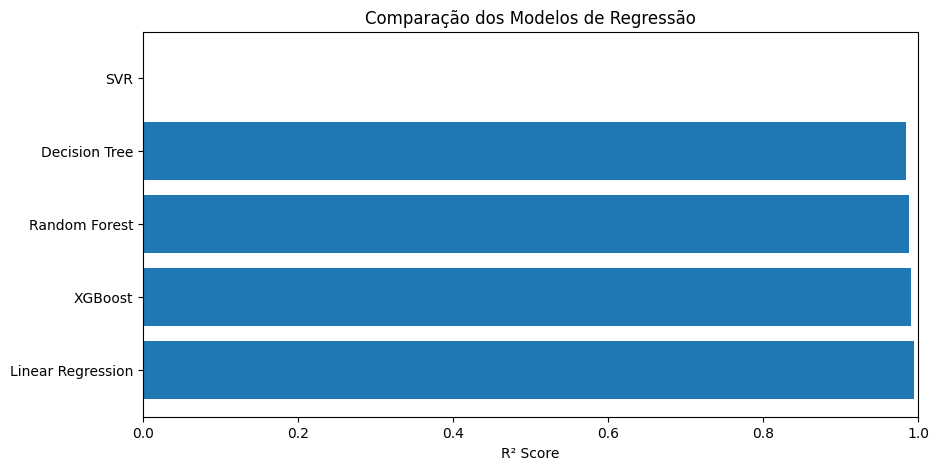

In [67]:
plt.figure(figsize=(10, 5))
plt.barh(df_resultados["Modelo"], df_resultados["R²"])
plt.xlabel("R² Score")
plt.title("Comparação dos Modelos de Regressão")
plt.xlim(0, 1)
plt.show()

##**D - CONCLUSÃO: ANÁLISE DAS MÉTRICAS DOS ALGORITMOS**

As métricas mostram, claramente, que o algoritmo Linear Regression teve o melhor resultado em todas as métricas:
Menor MAE (3.090), Menor MSE (19.054.512), Menor RMSE (4.365) e Maior R² (0,9951).
Esse resultado está em completa consonância com tudo que a EDA e a clusterização já mostraram:

1) O Yield é determinado quase exclusivamente pelo tipo de cultura;
2) Essa relação é essencialmente linear — cada cultura "adiciona" um valor fixo ao rendimento.

É exatamente esse tipo de análise que a regressão linear faz. O fato de o modelo mais simples ter superado modelos mais complexos (Random Forest, XGBoost) reforça que a estrutura dos dados é simples e bem capturada por uma relação linear.

Na outra extremidade, o SVR apresentou desempenho desastroso (R² = -0,31), sendo pior que simplesmente usar a média como previsão. Isso ocorre porque o SVR com kernel RBF é mais adequado para relações complexas entre variáveis contínuas, enquanto o nosso dataset é dominado por variáveis binárias (Crop) com relação linear ao Yield.

Em função disso, não resta dúvida que o modelo Linear Regression é o mais adequado para prever o rendimento da safra.


##**E - CROSS VALIDATION**

In [69]:
scores = cross_val_score(modelo_lr, X_train, y_train, cv=5, scoring="r2")
print(f"R² por fold: {scores}")
print(f"R² médio: {scores.mean():.4f} (+/- {scores.std():.4f})")

R² por fold: [0.97816023 0.98690069 0.98489874 0.98457222 0.99264854]
R² médio: 0.9854 (+/- 0.0047)


O Cross-Validation é uma técnica amplamente utilizada em machine learning e estatística para avaliar o desempenho de um modelo preditivo. É essencial para garantir que o modelo seja capaz de generalizar bem para novos dados e evitar overfitting.
No caso do modelo linear analisado, todos os indicadores foram positivos:

1) Os 5 folds tiveram R² entre 0,978 e 0,992 — todos muito altos;
2) O desvio padrão é apenas 0,0047 — variação mínima entre os folds;
3) O R² médio (0,9854) é consistente com o R² do teste (0,9951);

Isso confirma que o modelo é robusto, ou seja, que:

1)não depende de como os dados foram divididos;
2)não há sinal de overfitting.


##**F - ANÁLISE DOS RESÍDUOS**

A análise dos resíduos é a diferença entre o valor real e o previsto. Para que se confirme que o algoritmo tem um bom desempenho, os gráficos de análise de resíduos devem mostrar o seguinte:

1) **scatter de resíduos**: pontos devem estar distribuídos aleatoriamente em torno de 0. Se houver padrão (forma de funil, curva), o modelo está falhando em capturar algo;
2) **histograma**: deve aparecer uma distribuição normal (forma de sino centrada em 0).

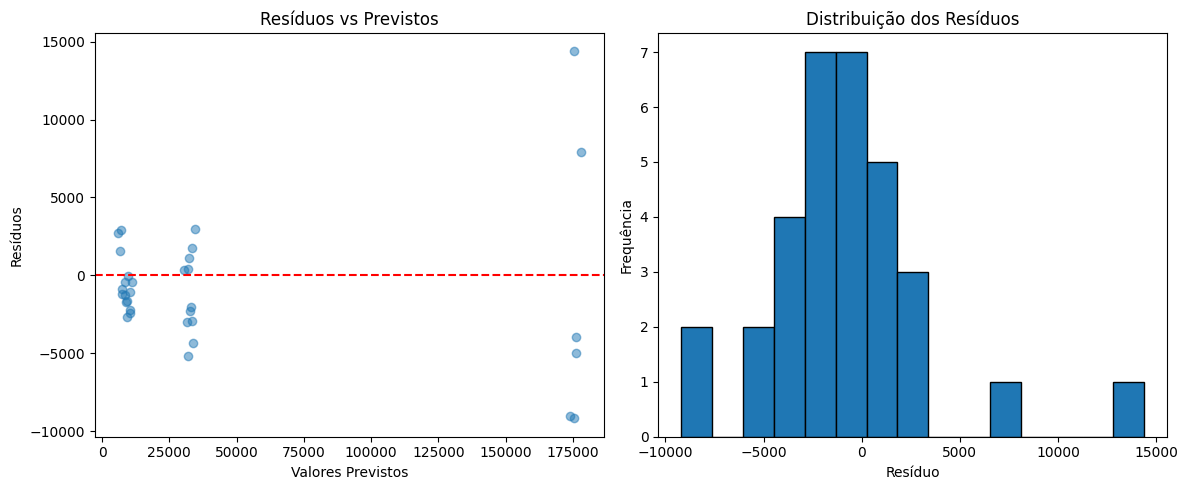

In [70]:
# Resíduos do melhor modelo
residuos = y_test - y_pred_lr

# Scatter: resíduos vs previstos
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_pred_lr, residuos, alpha=0.5)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Valores Previstos")
plt.ylabel("Resíduos")
plt.title("Resíduos vs Previstos")

# Histograma dos resíduos
plt.subplot(1, 2, 2)
plt.hist(residuos, bins=15, edgecolor="black")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos Resíduos")

plt.tight_layout()
plt.show()

#**INTERPRETAÇÃO DA ANÁLISE DE RESÍDUOS**

A análise resíduos confirma que o algoritmo teve um bom desempenho considerando as limitações do dataset:

1) Scatter: Os pontos de Oil palm fruit (~175.000 no eixo X) têm os maiores resíduos em valor absoluto — um chega a +15.000 e outro a quase -10.000. Porém, proporcionalmente, 15.000 de erro num Yield de 175.000 é ~8,5% — ainda aceitável. Já os pontos de Cocoa/Rubber (perto de 0 no eixo X) têm resíduos menores em valor absoluto, mas proporcionalmente maiores.

2) Histograma: Concentrado entre -5.000 e 5.000 com pico em torno de 0. Não é um sino perfeito, mas com apenas 32 registros de teste, é esperado. As barras isoladas nos extremos (-10.000 e +14.000) são provavelmente os registros de Oil palm fruit.

Um ponto importante: sem padrão de funil ou curva no scatter, o que confirma que o modelo não tem viés sistemático — erra para cima e para baixo de forma equilibrada.

Tudo isso aponta para um bom desempenho do algoritmo.

Em função disso, não resta dúvida que o modelo Linear Regression é o mais adequado para prever o rendimento da safra, no contexto do dataset analisado.

#**Conclusão — Regressão Supervisionada**

Cinco modelos de regressão foram treinados e avaliados para prever o rendimento agrícola (Yield): Linear Regression, Decision Tree Regressor, Random Forest Regressor, XGBoost e SVR.

**Resultados**

| Modelo | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | 3.090 | 4.365 | 0,9951 |
| XGBoost | 3.794 | 5.927 | 0,9909 |
| Random Forest | 3.555 | 6.809 | 0,9880 |
| Decision Tree | 3.858 | 7.710 | 0,9847 |
| SVR | 38.956 | 71.299 | -0,3105 |

**Melhor Modelo: Linear Regression**

A Linear Regression superou todos os demais modelos em todas as métricas, com um R² de 0,9951 — explicando 99,5% da variabilidade dos dados. A cross-validation com 5 folds confirmou a robustez do modelo (R² médio = 0,9854, desvio padrão = 0,0047), descartando qualquer sinal de overfitting. A análise de resíduos mostrou erros distribuídos de forma equilibrada em torno de zero, sem padrão sistemático de viés.

O fato de o modelo mais simples ter sido o melhor não é uma coincidência — é consequência direta da natureza dos dados, confirmando o que a EDA e a clusterização já haviam demonstrado: o rendimento é determinado quase exclusivamente pelo tipo de cultura. Cada cultura "adiciona" um valor fixo ao Yield, e é exatamente esse tipo de relação que a regressão linear captura de forma natural. Modelos mais complexos (Random Forest, XGBoost) não encontraram padrões adicionais para explorar, e o SVR não se adaptou à estrutura binária das features de Crop.

**Conexão entre as Três Etapas do Projeto**

As três etapas do projeto contam uma história coerente:

1) EDA (Tarefa 1): Identificou que o Yield é determinado pelo tipo de cultura, que as variáveis climáticas são compartilhadas entre as culturas e não apresentam correlação com o rendimento, e que Precipitação é a variável climática com maior variação;

2) Clusterização (Tarefa 2): Confirmou os padrões da EDA com métodos não supervisionados. O K-Means não conseguiu separar Cocoa beans de Rubber natural (rendimentos muito próximos), enquanto o DBSCAN separou as 4 culturas perfeitamente e identificou 12 outliers correspondentes a 3 condições climáticas atípicas;

3) Regressão (Tarefa 3): O modelo mais simples (Linear Regression) foi o melhor, confirmando que a relação entre features e Yield é linear e dominada por Crop. Os 4 modelos baseados em árvore não trouxeram ganho significativo porque não existem padrões não-lineares complexos a explorar.

**Limitações**

- *Dataset pequeno (156 registros)*: Limita a complexidade dos modelos e a confiabilidade das métricas. Com mais dados, modelos como Random Forest e XGBoost poderiam apresentar desempenho superior;

- *Variáveis climáticas com baixa variação e sem correlação com Yield*: As features climáticas contribuem pouco para os modelos. A inclusão de variáveis como tipo de solo, irrigação, fertilizantes e altitude poderia enriquecer significativamente a análise;

- *Dados climáticos compartilhados entre culturas*: O dataset apresenta os mesmos valores de Precipitação e Temperatura para todas as culturas num mesmo registro, o que limita a capacidade dos modelos de identificar interações entre clima e tipo de cultura;

- *SVR com desempenho negativo*: O SVR com kernel RBF e C=1.0 não se adaptou à estrutura dos dados. Uma otimização de hiperparâmetros (GridSearchCV) poderia melhorar o resultado, mas dificilmente superaria a Linear Regression dado a natureza linear do problema.

**Recomendação Final**

Para a FarmTech Solutions, o modelo de Linear Regression é a escolha recomendada para implantação na API de previsão de rendimento. Além de apresentar o melhor desempenho, sua simplicidade traz vantagens operacionais:

- menor custo computacional para hospedagem em nuvem;
- facilidade de interpretação para os agricultores, e
- transparência nos coeficientes que permite entender exatamente como cada variável influencia a previsão.

Para evoluções futuras, recomenda-se a coleta de dados adicionais (mais registros e mais variáveis) que possam enriquecer o modelo e eventualmente justificar o uso de algoritmos mais complexos.